# 04 Storage Sweep (Fear vs Extinction)

This notebook focuses **only on storage dynamics** (no retrieval beta terms).

Goal:
- reduce fear/extinction engram overlap (`phi`),
- preserve biologically sensible cue composition in each engram,
- identify robust storage parameter sets across random seeds.

Notes:
- Retrieval is intentionally omitted here.
- External drive is persistent during storage updates via `h = W @ s + field + theta`.
- `field` is built from binary cue vectors and storage betas only.

In [17]:
from pathlib import Path
import csv
from itertools import product

import numpy as np
import matplotlib.pyplot as plt

from engram.hopfield import HopfieldNetwork
from engram.patterns import generate_sparse_pattern


# Paths
_cwd = Path.cwd()
ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
OUTDIR = ROOT / "notebooks" / "figures"
OUTDIR.mkdir(parents=True, exist_ok=True)

print("Imports complete")

Imports complete


In [18]:
# Core model settings
N = 2000
SPARSITY = 0.10
K = int(SPARSITY * N)
P_OLD = 25
CUE_FRAC = 0.03
N_CUE = int(CUE_FRAC * N)

# Noise and dynamics
SIGMA_THETA = 0.01
MAX_STEPS_STORAGE = 20

# Reproducibility
BASE_SEED = 42

# Runtime profiles
# - FAST: exploratory (<~2h on many laptops)
# - MEDIUM: stronger ranking stability
# - DEEP: publication-grade storage-only pass
RUN_PROFILE = "FAST"  # change to "MEDIUM" or "DEEP"
SEEDS_BY_PROFILE = {
    "FAST": 4,
    "MEDIUM": 12,
    "DEEP": 30,
}
N_SEEDS = SEEDS_BY_PROFILE[RUN_PROFILE]

# Optional regime scan across memory load / cue size.
# Kept compact so FAST remains practical.
RUN_REGIME_SCAN = True
REGIME_SCENARIOS = [
    {"name": "baseline", "p_old": 25, "n_cue": int(0.03 * N)},
    {"name": "lower_load", "p_old": 15, "n_cue": int(0.03 * N)},
    {"name": "higher_load", "p_old": 35, "n_cue": int(0.03 * N)},
    {"name": "smaller_cue", "p_old": 25, "n_cue": int(0.02 * N)},
    {"name": "larger_cue", "p_old": 25, "n_cue": int(0.04 * N)},
]

# Fixed storage beta (fear US). Keep extinction US in the sweep.
BETA_US_FEAR_STORE = 0.20

# Chance-level overlap baseline
CHANCE = SPARSITY
TARGET_MARGIN = 0.03
TARGET_FLOOR = CHANCE + TARGET_MARGIN

print(
    f"profile={RUN_PROFILE} | N={N}, K={K}, P_OLD={P_OLD}, N_CUE={N_CUE}, seeds={N_SEEDS}, "
    f"target_floor={TARGET_FLOOR:.2f}, regime_scan={RUN_REGIME_SCAN}"
)

profile=FAST | N=2000, K=200, P_OLD=25, N_CUE=60, seeds=4, target_floor=0.13


In [19]:
def make_cue_component(n_neurons, n_active, rng):
    vec = np.zeros(n_neurons)
    idx = rng.choice(n_neurons, n_active, replace=False)
    vec[idx] = 1.0
    return vec


def compute_field(components, n_neurons):
    """Sum beta_i * cue_i across components (storage only)."""
    field = np.zeros(n_neurons)
    for vec, beta in components:
        field += beta * vec
    return field


def run_storage(net, init_state, field, theta, k, max_steps):
    state = init_state.copy().astype(float)
    for _ in range(max_steps):
        h = net.W @ state + field + theta
        idx = np.argpartition(h, -k)[-k:]
        new_state = np.zeros_like(state)
        new_state[idx] = 1.0
        if np.array_equal(new_state, state):
            break
        state = new_state
    return state


def frac_overlap(pattern, cue_vec, n_cue):
    return float(np.sum(pattern * cue_vec) / n_cue)


def phi_overlap(fear_engram, ext_engram, k):
    return float(np.sum(fear_engram * ext_engram) / k)


print("Helpers ready")

Helpers ready


In [20]:
# Storage-only sweep grid (profile-aware)
# Expanded where sensitivity was highest and where inhibition may break fear-copying.
GRID_PRESETS = {
    "FAST": {
        "beta_cs_fear_store": [0.05, 0.20, 0.35, 0.50, 0.65],
        "beta_cs_ext_store": [0.00, 0.08, 0.16],
        "beta_ctx_fear_store": [0.10, 0.35, 0.60, 0.85],
        "beta_ctx_ext_store": [0.10, 0.35, 0.60],
        "beta_us_ext_store": [-0.90, -0.60, -0.30, 0.00],
    },
    "MEDIUM": {
        "beta_cs_fear_store": [0.10, 0.20, 0.30, 0.40, 0.50, 0.60],
        "beta_cs_ext_store": [0.00, 0.05, 0.10, 0.15, 0.20],
        "beta_ctx_fear_store": [0.10, 0.25, 0.40, 0.55, 0.70, 0.85],
        "beta_ctx_ext_store": [0.10, 0.25, 0.40, 0.55, 0.70],
        "beta_us_ext_store": [-1.00, -0.80, -0.60, -0.40, -0.20, 0.00],
    },
    "DEEP": {
        "beta_cs_fear_store": [0.18, 0.24, 0.30, 0.36, 0.42, 0.48],
        "beta_cs_ext_store": [0.02, 0.06, 0.10, 0.14],
        "beta_ctx_fear_store": [0.22, 0.30, 0.38, 0.46, 0.54, 0.62],
        "beta_ctx_ext_store": [0.18, 0.28, 0.38, 0.48, 0.58],
        "beta_us_ext_store": [-0.80, -0.65, -0.50, -0.35, -0.20],
    },
}

GRID = GRID_PRESETS[RUN_PROFILE]
keys = list(GRID.keys())
combos = [dict(zip(keys, vals)) for vals in product(*(GRID[k] for k in keys))]
print(f"Total storage configs ({RUN_PROFILE}): {len(combos)}")

Total storage configs (FAST): 324


In [21]:
def evaluate_storage_config(cfg, seed, p_old=P_OLD, n_cue=N_CUE):
    rng = np.random.default_rng(seed)

    # Cues (binary)
    cs_vec = make_cue_component(N, n_cue, rng)
    us_vec = make_cue_component(N, n_cue, rng)
    ctx_fear_vec = make_cue_component(N, n_cue, rng)
    ctx_ext_vec = make_cue_component(N, n_cue, rng)

    # Network + old memories
    net = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=SPARSITY)
    old_patterns = [generate_sparse_pattern(N, SPARSITY, rng=rng).astype(float) for _ in range(p_old)]
    net.store_patterns(old_patterns)

    # Fear storage
    fear_components = [
        (cs_vec, cfg["beta_cs_fear_store"]),
        (us_vec, BETA_US_FEAR_STORE),
        (ctx_fear_vec, cfg["beta_ctx_fear_store"]),
    ]
    fear_field = compute_field(fear_components, N)
    theta_fear = rng.normal(0, SIGMA_THETA, N)
    fear_init = (fear_field > 0).astype(float)
    fear_engram = run_storage(net, fear_init, fear_field, theta_fear, K, MAX_STEPS_STORAGE)
    net.store_pattern_sequential(fear_engram)

    # Extinction storage (after fear)
    ext_components = [
        (cs_vec, cfg["beta_cs_ext_store"]),
        (us_vec, cfg["beta_us_ext_store"]),
        (ctx_ext_vec, cfg["beta_ctx_ext_store"]),
    ]
    ext_field = compute_field(ext_components, N)
    theta_ext = rng.normal(0, SIGMA_THETA, N)
    ext_init = (ext_field > 0).astype(float)
    ext_engram = run_storage(net, ext_init, ext_field, theta_ext, K, MAX_STEPS_STORAGE)
    net.store_pattern_sequential(ext_engram)

    # Storage metrics
    phi = phi_overlap(fear_engram, ext_engram, K)

    metrics = {
        "phi": phi,
        "fear_cs": frac_overlap(fear_engram, cs_vec, n_cue),
        "fear_us": frac_overlap(fear_engram, us_vec, n_cue),
        "fear_ctx_fear": frac_overlap(fear_engram, ctx_fear_vec, n_cue),
        "fear_ctx_ext": frac_overlap(fear_engram, ctx_ext_vec, n_cue),
        "ext_cs": frac_overlap(ext_engram, cs_vec, n_cue),
        "ext_us": frac_overlap(ext_engram, us_vec, n_cue),
        "ext_ctx_ext": frac_overlap(ext_engram, ctx_ext_vec, n_cue),
        "ext_ctx_fear": frac_overlap(ext_engram, ctx_fear_vec, n_cue),
        "shared_cs_frac": float(np.sum(fear_engram * ext_engram * cs_vec) / K),
    }
    return metrics


def summarize_config(cfg, base_seed=BASE_SEED, n_seeds=N_SEEDS, p_old=P_OLD, n_cue=N_CUE):
    per_seed = [evaluate_storage_config(cfg, base_seed + s, p_old=p_old, n_cue=n_cue) for s in range(n_seeds)]
    out = dict(cfg)

    for key in per_seed[0].keys():
        vals = np.array([m[key] for m in per_seed], dtype=float)
        out[f"{key}_mean"] = float(np.mean(vals))
        out[f"{key}_std"] = float(np.std(vals))

    # Useful derived diagnostics
    out["ctx_sep_ext_mean"] = float(out["ext_ctx_ext_mean"] - out["ext_ctx_fear_mean"])
    out["ctx_sep_fear_mean"] = float(out["fear_ctx_fear_mean"] - out["fear_ctx_ext_mean"])

    # Composite storage score (lower is better)
    # Objectives:
    # 1) low and stable fear/ext overlap (phi)
    # 2) target cue populations above chance
    # 3) context specificity (target context > non-target context)
    # 4) avoid excessive shared CS bridge
    phi_term = out["phi_mean"]
    phi_var_term = out["phi_std"]

    fear_target_penalty = (
        max(0.0, TARGET_FLOOR - out["fear_cs_mean"]) +
        max(0.0, TARGET_FLOOR - out["fear_us_mean"]) +
        max(0.0, TARGET_FLOOR - out["fear_ctx_fear_mean"])
    )

    ext_target_penalty = (
        max(0.0, TARGET_FLOOR - out["ext_cs_mean"]) +
        max(0.0, TARGET_FLOOR - out["ext_ctx_ext_mean"])
    )

    offtarget_penalty = (
        max(0.0, out["fear_ctx_ext_mean"] - (CHANCE + 0.01)) +
        max(0.0, out["ext_ctx_fear_mean"] - (CHANCE + 0.01))
    )

    ext_us_penalty = max(0.0, out["ext_us_mean"] - (CHANCE + 0.01))
    cs_bridge_penalty = max(0.0, out["shared_cs_frac_mean"] - 0.08)

    out["storage_score"] = float(
        4.0 * phi_term +
        2.0 * phi_var_term +
        2.0 * fear_target_penalty +
        2.0 * ext_target_penalty +
        1.2 * offtarget_penalty +
        0.8 * ext_us_penalty +
        0.8 * cs_bridge_penalty
    )
    return out


print("Evaluation functions ready")

Evaluation functions ready


In [22]:
# Run exhaustive storage sweep
results = []
for i, cfg in enumerate(combos, start=1):
    summary = summarize_config(cfg)
    results.append(summary)
    if i % 100 == 0 or i == len(combos):
        print(f"Processed {i}/{len(combos)}")

print("Sweep complete")

Processed 100/324
Processed 200/324
Processed 300/324
Processed 324/324
Sweep complete


In [23]:
# Rank and inspect best storage configs
results_sorted = sorted(results, key=lambda r: r["storage_score"])
TOP_N = 20
best = results_sorted[:TOP_N]

print(f"Top {TOP_N} storage configs (lowest storage_score):")
print(
    f"{'rank':<4} {'score':>8} {'phi':>7} {'phi_sd':>7} "
    f"{'fear_cs':>8} {'fear_us':>8} {'fear_ctxF':>10} "
    f"{'ext_cs':>8} {'ext_ctxE':>9} {'ctxSepE':>8} "
    f"{'b_cs_f':>7} {'b_cs_e':>7} {'b_ctx_f':>8} {'b_ctx_e':>8} {'b_us_e':>7}"
)
print("-" * 160)
for rank, r in enumerate(best, start=1):
    print(
        f"{rank:<4d} "
        f"{r['storage_score']:>8.3f} {r['phi_mean']:>7.3f} {r['phi_std']:>7.3f} "
        f"{r['fear_cs_mean']:>8.3f} {r['fear_us_mean']:>8.3f} {r['fear_ctx_fear_mean']:>10.3f} "
        f"{r['ext_cs_mean']:>8.3f} {r['ext_ctx_ext_mean']:>9.3f} {r['ctx_sep_ext_mean']:>8.3f} "
        f"{r['beta_cs_fear_store']:>7.2f} {r['beta_cs_ext_store']:>7.2f} "
        f"{r['beta_ctx_fear_store']:>8.2f} {r['beta_ctx_ext_store']:>8.2f} {r['beta_us_ext_store']:>7.2f}"
    )

print()
print(f"Chance baseline: {CHANCE:.2f}, target floor used in score: {TARGET_FLOOR:.2f}")

Top 20 storage configs (lowest storage_score):
rank    score     phi  phi_sd  fear_cs  fear_us  fear_ctxF   ext_cs  ext_ctxE  ctxSepE  b_cs_f  b_cs_e  b_ctx_f  b_ctx_e  b_us_e
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1       3.121   0.551   0.449    0.175    0.154      0.154    0.154     0.158    0.058    0.45    0.05     0.60     0.40   -0.45
2       3.122   0.547   0.453    0.167    0.154      0.146    0.150     0.162    0.054    0.30    0.15     0.60     0.20   -0.15
3       3.123   0.552   0.448    0.167    0.154      0.146    0.163     0.204    0.100    0.30    0.05     0.60     0.60   -0.45
4       3.123   0.552   0.448    0.167    0.154      0.146    0.158     0.179    0.075    0.30    0.05     0.60     0.60   -0.30
5       3.123   0.552   0.448    0.167    0.154      0.146    0.154     0.158    0.058    0.30    0.05     0.60     0.20   -0.45
6       3.123   0.

In [24]:
# Parameter sensitivity summary (main effects)
# This helps decide which dimensions deserve more runtime.


def grouped_mean(rows, param, metric):
    values = sorted({r[param] for r in rows})
    out = []
    for v in values:
        subset = [r for r in rows if r[param] == v]
        out.append((v, float(np.mean([s[metric] for s in subset]))))
    return out


metrics_to_track = [
    "storage_score",
    "phi_mean",
    "phi_std",
    "fear_cs_mean",
    "fear_us_mean",
    "fear_ctx_fear_mean",
    "ext_cs_mean",
    "ext_ctx_ext_mean",
    "ctx_sep_ext_mean",
]

for param in keys:
    print(f"\n=== Sensitivity: {param} ===")
    table = {m: grouped_mean(results_sorted, param, m) for m in metrics_to_track}

    header = f"{'value':>8} " + " ".join([f"{m:>14}" for m in metrics_to_track])
    print(header)
    print("-" * len(header))

    for i, (val, _) in enumerate(table["storage_score"]):
        row = [f"{val:>8.2f}"]
        for m in metrics_to_track:
            row.append(f"{table[m][i][1]:>14.3f}")
        print(" ".join(row))


# Compact guidance: identify highest-impact dimensions by score spread
spread = {}
for param in keys:
    vals = [v for _, v in grouped_mean(results_sorted, param, "storage_score")]
    spread[param] = float(max(vals) - min(vals))

print("\n=== Parameter impact (storage_score spread; larger => more sensitive) ===")
for k, v in sorted(spread.items(), key=lambda x: x[1], reverse=True):
    print(f"{k:<24} spread={v:.3f}")


=== Sensitivity: beta_cs_fear_store ===
   value  storage_score       phi_mean        phi_std   fear_cs_mean   fear_us_mean fear_ctx_fear_mean    ext_cs_mean ext_ctx_ext_mean ctx_sep_ext_mean
-------------------------------------------------------------------------------------------------------------------------------------------------------
    0.15          3.156          0.551          0.449          0.133          0.154          0.113          0.141          0.166          0.082
    0.30          3.168          0.558          0.447          0.144          0.154          0.124          0.147          0.166          0.076
    0.45          3.440          0.651          0.392          0.150          0.154          0.129          0.153          0.156          0.054

=== Sensitivity: beta_cs_ext_store ===
   value  storage_score       phi_mean        phi_std   fear_cs_mean   fear_us_mean fear_ctx_fear_mean    ext_cs_mean ext_ctx_ext_mean ctx_sep_ext_mean
-------------------------------

In [25]:
# Save full results to CSV
csv_path = OUTDIR / "04_storage_sweep_results.csv"
fieldnames = list(results_sorted[0].keys())

with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results_sorted)

print(f"Saved: {csv_path}")

Saved: c:\PhD_Data\engram-hopfield\notebooks\figures\04_storage_sweep_results.csv


## Regime scan (compact): memory load and cue size

This section tests whether overlap limits are caused by the beta grid alone or by a broader regime constraint.

- Uses the same storage-only objective.
- Re-runs sweep per scenario with modified `P_OLD` and `N_CUE`.
- Intended for `FAST` profile runtime budgeting.

In [ ]:
# Compact regime scan across P_OLD and N_CUE
regime_results = []

if RUN_REGIME_SCAN:
    if RUN_PROFILE != "FAST":
        print("Regime scan is tuned for FAST profile; skipping for non-FAST run.")
    else:
        for scenario in REGIME_SCENARIOS:
            print(f"Scenario: {scenario['name']} (P_OLD={scenario['p_old']}, N_CUE={scenario['n_cue']})")
            rows = []
            for i, cfg in enumerate(combos, start=1):
                summary = summarize_config(
                    cfg,
                    p_old=scenario["p_old"],
                    n_cue=scenario["n_cue"],
                )
                rows.append(summary)

                if i % 200 == 0 or i == len(combos):
                    print(f"  processed {i}/{len(combos)}")

            rows_sorted = sorted(rows, key=lambda r: r["storage_score"])
            top = rows_sorted[:20]

            regime_results.append({
                "scenario": scenario["name"],
                "p_old": scenario["p_old"],
                "n_cue": scenario["n_cue"],
                "best_storage_score": float(rows_sorted[0]["storage_score"]),
                "best_phi_mean": float(rows_sorted[0]["phi_mean"]),
                "best_phi_std": float(rows_sorted[0]["phi_std"]),
                "top20_phi_mean": float(np.mean([r["phi_mean"] for r in top])),
                "top20_storage_score_mean": float(np.mean([r["storage_score"] for r in top])),
                "top20_fear_ctx_fear_mean": float(np.mean([r["fear_ctx_fear_mean"] for r in top])),
                "top20_ext_ctx_ext_mean": float(np.mean([r["ext_ctx_ext_mean"] for r in top])),
                "top20_ext_cs_mean": float(np.mean([r["ext_cs_mean"] for r in top])),
            })

        # Plot scenario comparison
        scenario_names = [r["scenario"] for r in regime_results]
        phi_top20 = [r["top20_phi_mean"] for r in regime_results]
        score_top20 = [r["top20_storage_score_mean"] for r in regime_results]
        fear_ctx = [r["top20_fear_ctx_fear_mean"] for r in regime_results]
        ext_ctx = [r["top20_ext_ctx_ext_mean"] for r in regime_results]

        fig, axes = plt.subplots(1, 3, figsize=(18, 4))

        axes[0].bar(scenario_names, phi_top20, color="mediumpurple", alpha=0.85)
        axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="phi=0.5")
        axes[0].set_title("Top-20 phi_mean by regime")
        axes[0].set_ylabel("phi_mean")
        axes[0].tick_params(axis="x", rotation=20)
        axes[0].legend()

        axes[1].bar(scenario_names, score_top20, color="teal", alpha=0.85)
        axes[1].set_title("Top-20 storage_score by regime")
        axes[1].set_ylabel("storage_score")
        axes[1].tick_params(axis="x", rotation=20)

        x = np.arange(len(scenario_names))
        width = 0.38
        axes[2].bar(x - width / 2, fear_ctx, width=width, label="fear_ctx_fear", color="royalblue", alpha=0.85)
        axes[2].bar(x + width / 2, ext_ctx, width=width, label="ext_ctx_ext", color="darkorange", alpha=0.85)
        axes[2].axhline(CHANCE, color="gray", linestyle=":", linewidth=1, label="chance")
        axes[2].set_xticks(x)
        axes[2].set_xticklabels(scenario_names, rotation=20)
        axes[2].set_title("Top-20 target context overlap")
        axes[2].set_ylabel("overlap fraction")
        axes[2].legend()

        plt.tight_layout()
        regime_plot_path = OUTDIR / "04_storage_sweep_regime_scan.png"
        plt.savefig(regime_plot_path, dpi=150)
        plt.show()

        print("\nRegime scan summary:")
        for r in regime_results:
            print(
                f"{r['scenario']:<12} P_OLD={r['p_old']:<2d} N_CUE={r['n_cue']:<3d} "
                f"top20_phi={r['top20_phi_mean']:.3f} top20_score={r['top20_storage_score_mean']:.3f} "
                f"ctx_fear={r['top20_fear_ctx_fear_mean']:.3f} ctx_ext={r['top20_ext_ctx_ext_mean']:.3f}"
            )

        print(f"Saved: {regime_plot_path}")
else:
    print("RUN_REGIME_SCAN=False; skipping regime section.")

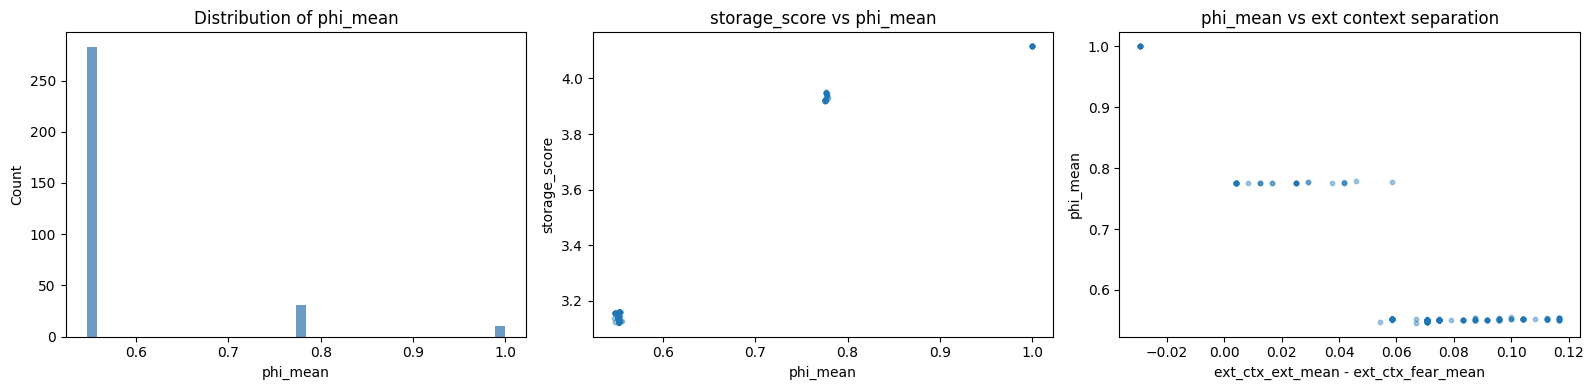

Saved: c:\PhD_Data\engram-hopfield\notebooks\figures\04_storage_sweep_overview.png


In [27]:
# Visual diagnostics over the full sweep
phi_vals = np.array([r["phi_mean"] for r in results_sorted])
score_vals = np.array([r["storage_score"] for r in results_sorted])
ctx_sep_vals = np.array([r["ext_ctx_ext_mean"] - r["ext_ctx_fear_mean"] for r in results_sorted])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(phi_vals, bins=40, color="steelblue", alpha=0.8)
axes[0].set_title("Distribution of phi_mean")
axes[0].set_xlabel("phi_mean")
axes[0].set_ylabel("Count")

axes[1].scatter(phi_vals, score_vals, s=10, alpha=0.4)
axes[1].set_title("storage_score vs phi_mean")
axes[1].set_xlabel("phi_mean")
axes[1].set_ylabel("storage_score")

axes[2].scatter(ctx_sep_vals, phi_vals, s=10, alpha=0.4)
axes[2].set_title("phi_mean vs ext context separation")
axes[2].set_xlabel("ext_ctx_ext_mean - ext_ctx_fear_mean")
axes[2].set_ylabel("phi_mean")

plt.tight_layout()
plot_path = OUTDIR / "04_storage_sweep_overview.png"
plt.savefig(plot_path, dpi=150)
plt.show()

print(f"Saved: {plot_path}")

## Next step (after storage-only selection)

This notebook optimizes **storage quality only**:
- lower fear/extinction overlap (`phi`),
- stronger-than-chance representation of target cue populations,
- better context specificity.

It does **not** guarantee retrieval behavior by itself.

After selecting finalists here, run a separate retrieval notebook that:
- keeps storage betas fixed from finalists,
- uses binary retrieval cues only (no retrieval betas),
- evaluates cue-conditional completion targets:
  - CS only: ambiguous or slight fear edge,
  - CS + fear context: fear wins,
  - CS + ext context: extinction wins,
  - CS + fear context + US: fear wins strongly.

Recommended workflow:
1. FAST profile for exploration and sensitivity.
2. MEDIUM profile focused around sensitive ranges.
3. DEEP profile only for the final shortlist (robustness confirmation).